# v4 (approach 1)

In [ ]:
!wget -q http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz
!mkdir -p /content/data/SpeechCommands/speech_commands_v0.01
!tar -xf speech_commands_v0.01.tar.gz -C /content/data/SpeechCommands/speech_commands_v0.01
!rm speech_commands_v0.01.tar.gz

In [ ]:
import torch
from transformers import (
    ASTFeatureExtractor,
    ASTForAudioClassification,
    TrainingArguments,
    Trainer,
)
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR
import numpy as np
import os
import random
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchaudio.datasets import SPEECHCOMMANDS
from tqdm.auto import tqdm
import json
# import evaluate

In [ ]:
TARGET_WORDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABELS = TARGET_WORDS + ["unknown", "silence"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = 12
SAMPLE_RATE = 16000
CLIP_LEN = 16000

class SC12(Dataset):
    def __init__(self, root, subset, train_fraction=1.0, valid_fraction=1.0, test_fraction=1.0):
        """
        Args:
            root:             Dataset root directory.
            subset:           One of "training", "validation", "testing".
            train_fraction:   Fraction of training data to keep (0.0–1.0).
            valid_fraction:   Fraction of validation data to keep (0.0–1.0).
            test_fraction:    Fraction of test data to keep (0.0–1.0).
        """
        self.base = SPEECHCOMMANDS(
            root=root,
            url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False,
            subset=subset,
        )
        self.subset = subset

        # Pick the right fraction for this split
        fraction = {"training": train_fraction, "validation": valid_fraction, "testing": test_fraction}[subset]

        # Bucket every sample into targets or unknowns
        targets_by_word = {w: [] for w in TARGET_WORDS}
        unknown_indices = []
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label in TARGET_WORDS:
                targets_by_word[label].append(i)
            elif label != "_background_noise_":
                unknown_indices.append(i)

        # Apply fraction per class (all splits)
        rng = random.Random(42)
        for w in TARGET_WORDS:
            idxs = targets_by_word[w]
            rng.shuffle(idxs)
            keep = max(1, int(len(idxs) * fraction))
            targets_by_word[w] = idxs[:keep]
        rng.shuffle(unknown_indices)
        unknown_indices = unknown_indices[:max(1, int(len(unknown_indices) * fraction))]

        # Flatten target indices
        self.target_indices = []
        for w in TARGET_WORDS:
            self.target_indices.extend(targets_by_word[w])

        # Match silence and unknown counts to the average target count
        avg_per_target = len(self.target_indices) // len(TARGET_WORDS)
        random.Random(0).shuffle(unknown_indices)
        self.unknown_indices = unknown_indices[:avg_per_target]
        self.n_silence = avg_per_target

        # Load background noise clips
        bg_dir = os.path.join(self.base._path, "_background_noise_")
        self.bg_clips = []
        for f in sorted(os.listdir(bg_dir)):
            if f.endswith(".wav"):
                wav, sr = torchaudio.load(os.path.join(bg_dir, f))
                self.bg_clips.append(wav.squeeze(0))

        # For val/test, use a fixed silence plan so evaluation is deterministic
        self.silence_plan = None
        if subset != "training":
            rng = random.Random(123)
            self.silence_plan = []
            for _ in range(self.n_silence):
                bi = rng.randrange(len(self.bg_clips))
                max_start = self.bg_clips[bi].size(0) - CLIP_LEN
                start = rng.randrange(max(1, max_start))
                scale = rng.uniform(0.0, 0.1)
                self.silence_plan.append((bi, start, scale))

    def __len__(self):
        return len(self.target_indices) + len(self.unknown_indices) + self.n_silence

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            pad_amount = CLIP_LEN - wav.size(0)
            return torch.nn.functional.pad(wav, (0, pad_amount))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        n_targets = len(self.target_indices)
        n_unknowns = len(self.unknown_indices)

        if idx < n_targets:
            wav, _, label, _, _ = self.base[self.target_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX[label]

        idx -= n_targets
        if idx < n_unknowns:
            wav, _, _, _, _ = self.base[self.unknown_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX["unknown"]

        idx -= n_unknowns
        if self.silence_plan is not None:
            bi, start, scale = self.silence_plan[idx]
        else:
            bi = random.randrange(len(self.bg_clips))
            max_start = self.bg_clips[bi].size(0) - CLIP_LEN
            start = random.randrange(max(1, max_start))
            scale = random.uniform(0.0, 0.1)
        wav = self.bg_clips[bi][start:start + CLIP_LEN] * scale
        wav = self.pad_or_trim(wav)
        return wav, LABEL2IDX["silence"]


# def make_ast_collate(feature_extractor):
#     def collate(batch):
#         wavs, labels = zip(*batch)
#         wavs_np = [w.numpy() for w in wavs]
#         inputs = feature_extractor(wavs_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")
#         inputs["labels"] = torch.tensor(labels, dtype=torch.long)
#         return inputs
#     return collate

import torchaudio.transforms as T

def make_ast_collate(feature_extractor, spec_augment=False,
                     freq_mask_param=24, time_mask_param=25,
                     n_freq_masks=2, n_time_masks=2):
    """If spec_augment=True, applies SpecAugment to the mel-spectrogram.
    Used only for training; eval should use spec_augment=False."""
    freq_mask = T.FrequencyMasking(freq_mask_param=freq_mask_param)
    time_mask = T.TimeMasking(time_mask_param=time_mask_param)

    def collate(batch):
        wavs, labels = zip(*batch)
        wavs_np = [w.numpy() for w in wavs]
        inputs = feature_extractor(wavs_np, sampling_rate=SAMPLE_RATE, return_tensors="pt")

        if spec_augment:
            x = inputs["input_values"]
            for _ in range(n_freq_masks):
                x = freq_mask(x)
            for _ in range(n_time_masks):
                x = time_mask(x)
            inputs["input_values"] = x

        inputs["labels"] = torch.tensor(labels, dtype=torch.long)
        return inputs
    return collate

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
root="/content/data"

# original split: train ~22 000, valid 3091, test: 3079
train_ds = SC12(root, "training", train_fraction=1.0)
val_ds = SC12(root, "validation", valid_fraction=1.0)
test_ds = SC12(root, "testing",  test_fraction=1.0)

print(f"train {len(train_ds)}")
print(f"valid {len(val_ds)}")
print(f"test {len(test_ds)}")


device: cuda
train 22244
valid 3091
test 3079


In [ ]:
def compute_dataset_stats(dataset, feature_extractor, n_samples=2000):
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    feature_extractor.do_normalize = False

    all_means, all_stds = [], []
    for i in indices:
        x, _ = dataset[i]
        feats = feature_extractor(x.numpy(), sampling_rate=16000, return_tensors="pt")["input_values"]
        all_means.append(feats.mean().item())
        all_stds.append(feats.std().item())

    return sum(all_means) / len(all_means), sum(all_stds) / len(all_stds)

In [ ]:
MODEL_ID = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_ID)
mean, std = compute_dataset_stats(train_ds, feature_extractor)
# !! Compute these from YOUR dataset, or fall back to AudioSet defaults
# from transformers import ASTFeatureExtractor
feature_extractor.mean = mean
feature_extractor.std  = std
feature_extractor.do_normalize = True
# collate = make_ast_collate(feature_extractor)

collate = make_ast_collate(feature_extractor, spec_augment=False)            # plain (eval + non-12-class training)
collate_aug = make_ast_collate(feature_extractor, spec_augment=True)         # SpecAugment for the 12-class baseline

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [ ]:
from transformers import set_seed
seed = 2504
set_seed(seed)
random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # multi-GPU

# Ensures deterministic behavior (at a performance cost)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# For newer PyTorch versions (recommended)
torch.use_deterministic_algorithms(True)

import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
# ── Labels ────────────────────────────────────────────────────────────────
label2id = {
    "yes": 0, "no": 1, "up": 2, "down": 3, "left": 4,
    "right": 5, "on": 6, "off": 7, "stop": 8, "go": 9,
    "unknown": 10, "silence": 11,
}
id2label = {v: k for k, v in label2id.items()}
num_labels = 12

# ── Model ──────────────────────────────────────────────────────────────────
model = ASTForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=12,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # replaces the 527-class AudioSet head
)

# ── 4. Preprocessing ──────────────────────────────────────────────────────────
def preprocess(batch):
    wavs = [np.array(a["array"], dtype=np.float32) for a in batch["audio"]]
    inputs = feature_extractor(
        wavs,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True,
    )
    inputs["labels"] = torch.tensor(
        [label2id[l] for l in batch["label"]], dtype=torch.long
    )
    return inputs

# ── 5. Metrics ────────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

# ── 6. Training arguments ─────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./ast-speech-commands",
    seed=seed,
    data_seed=seed,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=8,    # keep effective batch = 128
    gradient_checkpointing=True,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=1,
    num_train_epochs=4,
    fp16=True,
    weight_decay=1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=3,
    logging_steps=10,
    logging_strategy="steps",
    report_to="none",
)

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     data_collator=collate,
#     compute_metrics=compute_metrics
# )

# Special for augmentaion
class TrainEvalCollator:
    def __init__(self, train_collate, eval_collate, model):
        self.train_collate = train_collate
        self.eval_collate = eval_collate
        self.model = model
    def __call__(self, batch):
        return self.train_collate(batch) if self.model.training else self.eval_collate(batch)

collate_12 = TrainEvalCollator(collate_aug, collate, model)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_12,        # SpecAugment ON for training, OFF for eval
    compute_metrics=compute_metrics,
)

# trainer.train()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([12, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([12])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.305839,0.238364,0.928826
2,0.229787,0.169234,0.946296
3,0.089576,0.148042,0.958589


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
config = {
    "learning_rate": training_args.learning_rate,
    "weight_decay": training_args.weight_decay,
    "model_name": "ast",
    "log_history": trainer.state.log_history,
}

with open(f"drive/MyDrive/results/history_{timestamp}.json", "w") as f:
    json.dump(config, f, indent=2)


Test Accuracy: 0.9633
              precision    recall  f1-score   support

         yes       0.98      0.98      0.98       256
          no       0.96      0.95      0.96       252
          up       0.94      0.97      0.96       272
        down       0.96      0.94      0.95       253
        left       0.97      0.99      0.98       267
       right       0.99      0.95      0.97       259
          on       0.97      0.96      0.97       246
         off       0.94      0.97      0.95       262
        stop       0.98      0.99      0.98       249
          go       0.96      0.92      0.94       251
     unknown       0.92      0.93      0.92       256
     silence       0.99      1.00      1.00       256

    accuracy                           0.96      3079
   macro avg       0.96      0.96      0.96      3079
weighted avg       0.96      0.96      0.96      3079



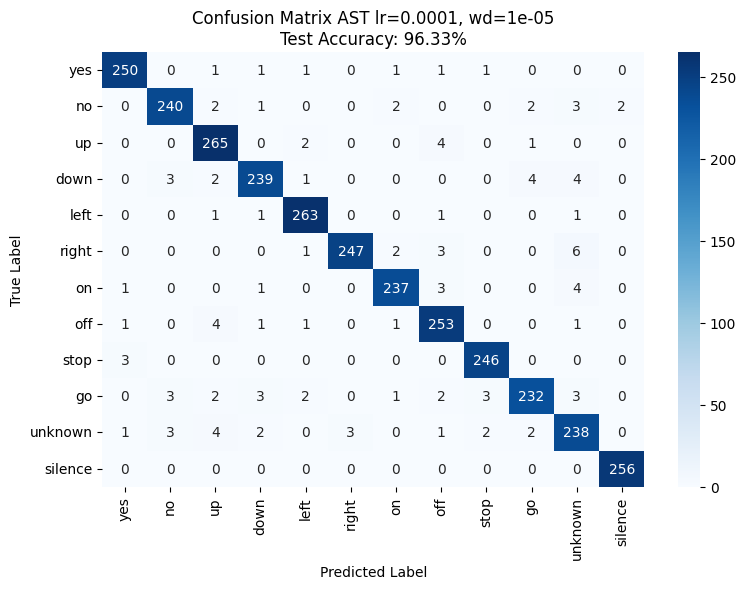

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from transformers import Trainer

# 2. Run predictions on the test set
predictions_output = trainer.predict(test_ds)

logits = predictions_output.predictions          # raw logits, shape (N, num_labels)
labels = predictions_output.label_ids            # true labels, shape (N,)
preds  = np.argmax(logits, axis=-1)              # predicted class indices

# 3. Compute accuracy
accuracy = accuracy_score(labels, preds)
print(f"Test Accuracy: {accuracy:.4f}")

# 4. Full classification report
label_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "unknown", "silence"]
print(classification_report(labels, preds, target_names=label_names))

# 5. Confusion matrix
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Confusion Matrix AST lr={training_args.learning_rate}, wd={training_args.weight_decay}\nTest Accuracy: {accuracy:.2%}")
plt.tight_layout()
plt.savefig(f"drive/MyDrive/results/matrix_full_aug_{timestamp}.png", dpi=150)
plt.show()

# Approach 2


## Approach 2: 11-class classifier + confidence threshold for unknown

Train an 11-class model (10 target words + silence). At inference, if the max softmax probability is below a tuned threshold, classify as "unknown". The threshold is tuned on the validation set.


In [ ]:
# ── Approach 1: dataset with only 10 words + silence (no unknown) ──────────
LABELS_11 = TARGET_WORDS + ["silence"]
LABEL2IDX_11 = {l: i for i, l in enumerate(LABELS_11)}
NUM_CLASSES_11 = 11

class SC11_NoUnknown(Dataset):
    """10 target words + silence. Unknown words are dropped from training/val."""
    def __init__(self, root, subset, train_fraction=1.0, valid_fraction=1.0, test_fraction=1.0):
        self.base = SPEECHCOMMANDS(
            root=root,
            url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False,
            subset=subset,
        )
        self.subset = subset
        fraction = {"training": train_fraction, "validation": valid_fraction, "testing": test_fraction}[subset]

        # Bucket only target words (skip non-target words and background noise)
        targets_by_word = {w: [] for w in TARGET_WORDS}
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label in TARGET_WORDS:
                targets_by_word[label].append(i)

        rng = random.Random(42)
        for w in TARGET_WORDS:
            idxs = targets_by_word[w]
            rng.shuffle(idxs)
            keep = max(1, int(len(idxs) * fraction))
            targets_by_word[w] = idxs[:keep]

        self.target_indices = []
        for w in TARGET_WORDS:
            self.target_indices.extend(targets_by_word[w])

        # Silence count matches avg target count (consistent with baseline)
        avg_per_target = len(self.target_indices) // len(TARGET_WORDS)
        self.n_silence = avg_per_target

        bg_dir = os.path.join(self.base._path, "_background_noise_")
        self.bg_clips = []
        for f in sorted(os.listdir(bg_dir)):
            if f.endswith(".wav"):
                wav, sr = torchaudio.load(os.path.join(bg_dir, f))
                self.bg_clips.append(wav.squeeze(0))

        self.silence_plan = None
        if subset != "training":
            rng = random.Random(123)
            self.silence_plan = []
            for _ in range(self.n_silence):
                bi = rng.randrange(len(self.bg_clips))
                max_start = self.bg_clips[bi].size(0) - CLIP_LEN
                start = rng.randrange(max(1, max_start))
                scale = rng.uniform(0.0, 0.1)
                self.silence_plan.append((bi, start, scale))

    def __len__(self):
        return len(self.target_indices) + self.n_silence

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            return torch.nn.functional.pad(wav, (0, CLIP_LEN - wav.size(0)))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        n_targets = len(self.target_indices)
        if idx < n_targets:
            wav, _, label, _, _ = self.base[self.target_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX_11[label]

        idx -= n_targets
        if self.silence_plan is not None:
            bi, start, scale = self.silence_plan[idx]
        else:
            bi = random.randrange(len(self.bg_clips))
            max_start = self.bg_clips[bi].size(0) - CLIP_LEN
            start = random.randrange(max(1, max_start))
            scale = random.uniform(0.0, 0.1)
        wav = self.bg_clips[bi][start:start + CLIP_LEN] * scale
        wav = self.pad_or_trim(wav)
        return wav, LABEL2IDX_11["silence"]


# Build datasets (uses same fractions as your baseline)
train_ds_11 = SC11_NoUnknown(root, "training", train_fraction=0.1)
val_ds_11   = SC11_NoUnknown(root, "validation", valid_fraction=0.66)
# Note: test set stays 12-class (we evaluate on the original test set)
print(f"train (11-class) {len(train_ds_11)}")
print(f"valid (11-class) {len(val_ds_11)}")


train (11-class) 2035
valid (11-class) 1865


In [ ]:
# ── Approach 1: train 11-class model ───────────────────────────────────────
from transformers import set_seed
seed = 2504
set_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

label2id_11 = {**{w: i for i, w in enumerate(TARGET_WORDS)}, "silence": 10}
id2label_11 = {v: k for k, v in label2id_11.items()}

from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

model_11 = ASTForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=11,
    label2id=label2id_11,
    id2label=id2label_11,
    ignore_mismatched_sizes=True,
)

training_args_11 = TrainingArguments(
    output_dir="./ast-sc-11class",
    seed=seed,
    data_seed=seed,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=1,
    num_train_epochs=8,
    fp16=True,
    weight_decay=1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=3,
    logging_steps=10,
    logging_strategy="steps",
    report_to="none",
)

trainer_11 = Trainer(
    model=model_11,
    args=training_args_11,
    train_dataset=train_ds_11,
    eval_dataset=val_ds_11,
    data_collator=collate,
    compute_metrics=compute_metrics,
)

trainer_11.train()


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([11])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([11, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch,Training Loss,Validation Loss,Accuracy
1,2.115032,0.730009,0.779088
2,0.312489,0.451871,0.853083
3,0.141713,0.463228,0.854155
4,0.042967,0.408046,0.885791
5,0.019142,0.381625,0.899196
6,0.008413,0.400723,0.894906
7,0.005536,0.409709,0.893834
8,0.004154,0.406806,0.895442


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=128, training_loss=0.278544022643473, metrics={'train_runtime': 1835.821, 'train_samples_per_second': 8.868, 'train_steps_per_second': 0.07, 'total_flos': 1.1035932438193766e+18, 'train_loss': 0.278544022643473, 'epoch': 8.0})

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
config = {
    "learning_rate": training_args_11.learning_rate,
    "weight_decay": training_args_11.weight_decay,
    "model_name": "ast_11_class",
    "log_history": trainer_11.state.log_history,
}

with open(f"drive/MyDrive/results/history_2_{timestamp}.json", "w") as f:
    json.dump(config, f, indent=2)

NameError: name 'training_args_11' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Approach 1: tune threshold on validation, evaluate on 12-class test ────
import torch.nn.functional as F
from torch.utils.data import DataLoader

# We need val/test data that includes unknown words to tune the threshold
# and measure final 12-class performance. Reuse the original SC12 splits.
val_ds_12_for_thresh = val_ds   # the 12-class validation set you already have
test_ds_12 = test_ds            # the 12-class test set you already have

@torch.no_grad()
def get_probs_and_labels(model, dataset, collate_fn, batch_size=16):
    """Run inference without computing loss (avoids CUDA assert when label
    space differs from model's num_labels). Returns (probs, true_12class_labels)."""
    model.eval()
    device = next(model.parameters()).device
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)
    all_probs, all_labels = [], []
    for batch in loader:
        labels = batch.pop("labels")  # keep aside, don't send to model
        inputs = {k: v.to(device) for k, v in batch.items()}
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# Map 11-class model output -> 12-class label space using a threshold
# 11-class model labels: 0..9 = words, 10 = silence
# 12-class label space:  0..9 = words, 10 = unknown, 11 = silence
def probs_to_12class(probs, threshold):
    pred_11 = probs.argmax(axis=-1)
    max_prob = probs.max(axis=-1)
    pred_12 = np.empty_like(pred_11)
    for i in range(len(pred_11)):
        if max_prob[i] < threshold:
            pred_12[i] = LABEL2IDX["unknown"]   # 10
        else:
            # remap: 11-class silence (10) -> 12-class silence (11); words unchanged
            pred_12[i] = 11 if pred_11[i] == 10 else pred_11[i]
    return pred_12

# Get probs on 12-class validation set (which DOES contain unknown samples)
val_probs, val_labels_12 = get_probs_and_labels(trainer_11.model, val_ds_12_for_thresh, collate)

# Diagnostic: show max-prob distributions for known vs unknown samples
val_max_probs = val_probs.max(axis=-1)
is_unknown = (val_labels_12 == LABEL2IDX["unknown"])
print(f"max-prob on known:   {val_max_probs[~is_unknown].mean():.3f} ± {val_max_probs[~is_unknown].std():.3f}")
print(f"max-prob on unknown: {val_max_probs[is_unknown].mean():.3f} ± {val_max_probs[is_unknown].std():.3f}")

plt.figure(figsize=(7, 4))
plt.hist(val_max_probs[~is_unknown], bins=50, alpha=0.5, label="known (words+silence)")
plt.hist(val_max_probs[is_unknown], bins=50, alpha=0.5, label="unknown")
plt.xlabel("max softmax probability"); plt.ylabel("count"); plt.legend()
plt.title("Confidence distribution: known vs unknown (validation)")
plt.tight_layout(); plt.show()

# Sweep thresholds, pick best by 12-class accuracy
thresholds = np.linspace(1/11, 0.8, 10)
best_thresh, best_acc = thresholds[0], 0.0
for t in thresholds:
    preds_12 = probs_to_12class(val_probs, t)
    acc = accuracy_score(val_labels_12, preds_12)
    if acc > best_acc:
        best_acc, best_thresh = acc, t

print(f"Best threshold on validation: {best_thresh:.3f}  (val acc: {best_acc:.4f})")

# Evaluate on the 12-class test set with the chosen threshold
test_probs, test_labels_12 = get_probs_and_labels(trainer_11.model, test_ds_12, collate)
test_preds_12 = probs_to_12class(test_probs, best_thresh)

test_acc_a1 = accuracy_score(test_labels_12, test_preds_12)
print(f"Approach 2, Test Accuracy (12-class): {test_acc_a1:.4f}")
print(classification_report(test_labels_12, test_preds_12, target_names=LABELS))

cm_a1 = confusion_matrix(test_labels_12, test_preds_12)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_a1, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Approach 2, Confusion Matrix, Test Acc: {test_acc_a1:.2%}, thresh={best_thresh:.2f}")
plt.tight_layout()
plt.savefig(f"drive/MyDrive/results/matrix_a2_{timestamp}.png", dpi=150)
plt.show()

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# ── Approach 2: save run history ───────────────────────────────────────────
timestamp_a1 = datetime.now().strftime("%Y%m%d%H%M%S")
config_a1 = {
    "approach": "1_threshold_unknown",
    "learning_rate": training_args_11.learning_rate,
    "weight_decay": training_args_11.weight_decay,
    "model_name": "ast_11class",
    "best_threshold": float(best_thresh),
    "test_accuracy": float(test_acc_a1),
    "log_history": trainer_11.state.log_history,
}
with open(f"drive/MyDrive/results/history_a1_{timestamp_a1}.json", "w") as f:
    json.dump(config_a1, f, indent=2)


# Approach 3


## Approach 3: silence detector + 11-class word/unknown model

Two specialized models:
1. **Silence detector** (binary): silence vs. non-silence
2. **Word classifier** (11-class): 10 target words + unknown

At inference: if the silence detector fires, predict silence; otherwise pass to the word classifier.


In [ ]:
# ── Approach 2a: binary silence-vs-non-silence dataset ─────────────────────
class SC_SilenceBinary(Dataset):
    """Binary: 0 = non-silence (any word), 1 = silence.
    Uses oversampled silence (multiple random crops per bg clip) to match
    the count of non-silence samples — preserves all the speech data."""

    NON_SILENCE = 0
    SILENCE = 1

    def __init__(self, root, subset, train_fraction=1.0, valid_fraction=1.0, test_fraction=1.0):
        self.base = SPEECHCOMMANDS(
            root=root, url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False, subset=subset,
        )
        self.subset = subset
        fraction = {"training": train_fraction, "validation": valid_fraction, "testing": test_fraction}[subset]

        # Collect all word indices (target + non-target), skip background
        word_indices = []
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label != "_background_noise_":
                word_indices.append(i)

        rng = random.Random(42)
        rng.shuffle(word_indices)
        keep = max(1, int(len(word_indices) * fraction))
        self.word_indices = word_indices[:keep]

        # Match silence count to non-silence count (oversampled crops)
        self.n_silence = len(self.word_indices)

        bg_dir = os.path.join(self.base._path, "_background_noise_")
        self.bg_clips = []
        for f in sorted(os.listdir(bg_dir)):
            if f.endswith(".wav"):
                wav, sr = torchaudio.load(os.path.join(bg_dir, f))
                self.bg_clips.append(wav.squeeze(0))

        self.silence_plan = None
        if subset != "training":
            rng = random.Random(123)
            self.silence_plan = []
            for _ in range(self.n_silence):
                bi = rng.randrange(len(self.bg_clips))
                max_start = self.bg_clips[bi].size(0) - CLIP_LEN
                start = rng.randrange(max(1, max_start))
                scale = rng.uniform(0.0, 0.1)
                self.silence_plan.append((bi, start, scale))

    def __len__(self):
        return len(self.word_indices) + self.n_silence

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            return torch.nn.functional.pad(wav, (0, CLIP_LEN - wav.size(0)))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        if idx < len(self.word_indices):
            wav, _, _, _, _ = self.base[self.word_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), self.NON_SILENCE

        idx -= len(self.word_indices)
        if self.silence_plan is not None:
            bi, start, scale = self.silence_plan[idx]
        else:
            bi = random.randrange(len(self.bg_clips))
            max_start = self.bg_clips[bi].size(0) - CLIP_LEN
            start = random.randrange(max(1, max_start))
            scale = random.uniform(0.0, 0.1)
        wav = self.bg_clips[bi][start:start + CLIP_LEN] * scale
        return self.pad_or_trim(wav), self.SILENCE


# Build silence-detector datasets. We use a smaller fraction here because
# the binary task is easy and converges fast.
sil_train_ds = SC_SilenceBinary(root, "training", train_fraction=0.05)
sil_val_ds   = SC_SilenceBinary(root, "validation", valid_fraction=0.66)
print(f"silence-detector train: {len(sil_train_ds)}")
print(f"silence-detector valid: {len(sil_val_ds)}")


In [ ]:
# ── Approach 2a: train silence detector (binary) ───────────────────────────
set_seed(seed)
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

label2id_sil = {"non_silence": 0, "silence": 1}
id2label_sil = {v: k for k, v in label2id_sil.items()}

model_sil = ASTForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=2,
    label2id=label2id_sil,
    id2label=id2label_sil,
    ignore_mismatched_sizes=True,
)

training_args_sil = TrainingArguments(
    output_dir="./ast-sc-silence-binary",
    seed=seed,
    data_seed=seed,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    learning_rate=2.5e-4,
    lr_scheduler_type="cosine",
    warmup_steps=1,
    num_train_epochs=3,           # binary task converges fast
    fp16=True,
    weight_decay=1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=10,
    logging_strategy="steps",
    report_to="none",
)

trainer_sil = Trainer(
    model=model_sil,
    args=training_args_sil,
    train_dataset=sil_train_ds,
    eval_dataset=sil_val_ds,
    data_collator=collate,
    compute_metrics=compute_metrics,
)

trainer_sil.train()


In [ ]:
# ── Approach 2b: 11-class dataset (10 words + unknown), no silence ─────────
LABELS_WORDS = TARGET_WORDS + ["unknown"]
LABEL2IDX_WORDS = {l: i for i, l in enumerate(LABELS_WORDS)}

class SC11_WordsUnknown(Dataset):
    """10 target words + unknown. No silence (handled by the cascade's first stage)."""
    def __init__(self, root, subset, train_fraction=1.0, valid_fraction=1.0, test_fraction=1.0):
        self.base = SPEECHCOMMANDS(
            root=root, url="speech_commands_v0.01",
            folder_in_archive="SpeechCommands",
            download=False, subset=subset,
        )
        self.subset = subset
        fraction = {"training": train_fraction, "validation": valid_fraction, "testing": test_fraction}[subset]

        targets_by_word = {w: [] for w in TARGET_WORDS}
        unknown_indices = []
        for i in range(len(self.base)):
            label = self.base.get_metadata(i)[2]
            if label in TARGET_WORDS:
                targets_by_word[label].append(i)
            elif label != "_background_noise_":
                unknown_indices.append(i)

        rng = random.Random(42)
        for w in TARGET_WORDS:
            idxs = targets_by_word[w]
            rng.shuffle(idxs)
            keep = max(1, int(len(idxs) * fraction))
            targets_by_word[w] = idxs[:keep]
        rng.shuffle(unknown_indices)
        unknown_indices = unknown_indices[:max(1, int(len(unknown_indices) * fraction))]

        self.target_indices = []
        for w in TARGET_WORDS:
            self.target_indices.extend(targets_by_word[w])

        # Match unknown count to avg per-target count (same scheme as baseline)
        avg_per_target = len(self.target_indices) // len(TARGET_WORDS)
        random.Random(0).shuffle(unknown_indices)
        self.unknown_indices = unknown_indices[:avg_per_target]

    def __len__(self):
        return len(self.target_indices) + len(self.unknown_indices)

    def pad_or_trim(self, wav):
        if wav.size(0) < CLIP_LEN:
            return torch.nn.functional.pad(wav, (0, CLIP_LEN - wav.size(0)))
        return wav[:CLIP_LEN]

    def __getitem__(self, idx):
        n_targets = len(self.target_indices)
        if idx < n_targets:
            wav, _, label, _, _ = self.base[self.target_indices[idx]]
            return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX_WORDS[label]
        idx -= n_targets
        wav, _, _, _, _ = self.base[self.unknown_indices[idx]]
        return self.pad_or_trim(wav.squeeze(0)), LABEL2IDX_WORDS["unknown"]


words_train_ds = SC11_WordsUnknown(root, "training", train_fraction=0.1)
words_val_ds   = SC11_WordsUnknown(root, "validation", valid_fraction=0.66)
print(f"words-classifier train: {len(words_train_ds)}")
print(f"words-classifier valid: {len(words_val_ds)}")


In [ ]:
# ── Approach 2b: train 11-class word/unknown classifier ────────────────────
set_seed(seed)
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

label2id_words = {**{w: i for i, w in enumerate(TARGET_WORDS)}, "unknown": 10}
id2label_words = {v: k for k, v in label2id_words.items()}

model_words = ASTForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=11,
    label2id=label2id_words,
    id2label=id2label_words,
    ignore_mismatched_sizes=True,
)

training_args_words = TrainingArguments(
    output_dir="./ast-sc-words-unknown",
    seed=seed,
    data_seed=seed,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    learning_rate=2.5e-4,
    lr_scheduler_type="cosine",
    warmup_steps=1,
    num_train_epochs=8,
    fp16=True,
    weight_decay=1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=3,
    logging_steps=10,
    logging_strategy="steps",
    report_to="none",
)

trainer_words = Trainer(
    model=model_words,
    args=training_args_words,
    train_dataset=words_train_ds,
    eval_dataset=words_val_ds,
    data_collator=collate,
    compute_metrics=compute_metrics,
)

trainer_words.train()


In [ ]:
# ── Approach 2: cascade evaluation on 12-class test set ────────────────────
# Pipeline: silence detector first; if non-silence, hand off to word classifier.

# Get silence-detector probs on the 12-class test set
sil_out = trainer_sil.predict(test_ds)
sil_probs = F.softmax(torch.tensor(sil_out.predictions), dim=-1).numpy()
test_labels_12 = sil_out.label_ids  # ground truth in 12-class space

# Get word-classifier probs on the same test set
words_out = trainer_words.predict(test_ds)
words_probs = F.softmax(torch.tensor(words_out.predictions), dim=-1).numpy()

# Tune the silence-detector threshold on the validation set (12-class)
sil_val_out = trainer_sil.predict(val_ds)
sil_val_probs = F.softmax(torch.tensor(sil_val_out.predictions), dim=-1).numpy()
words_val_out = trainer_words.predict(val_ds)
words_val_probs = F.softmax(torch.tensor(words_val_out.predictions), dim=-1).numpy()
val_labels_12 = sil_val_out.label_ids

def cascade_predict(sil_p, words_p, sil_thresh):
    """If P(silence) >= sil_thresh -> silence (12-class idx 11);
    else use word classifier output, mapping its 'unknown' (10) -> 12-class idx 10."""
    preds_12 = np.empty(len(sil_p), dtype=np.int64)
    is_silence = sil_p[:, 1] >= sil_thresh
    word_pred = words_p.argmax(axis=-1)  # 0..9 words, 10 = unknown
    for i in range(len(preds_12)):
        if is_silence[i]:
            preds_12[i] = 11   # silence
        else:
            # words 0..9 stay; words-classifier "unknown" (10) -> 12-class "unknown" (10)
            preds_12[i] = word_pred[i]
    return preds_12

thresholds = np.linspace(0.30, 0.95, 27)
best_thresh_a2, best_acc_a2 = 0.5, 0.0
for t in thresholds:
    preds_v = cascade_predict(sil_val_probs, words_val_probs, t)
    acc = accuracy_score(val_labels_12, preds_v)
    if acc > best_acc_a2:
        best_acc_a2, best_thresh_a2 = acc, t

print(f"Best silence threshold on validation: {best_thresh_a2:.3f}  (val acc: {best_acc_a2:.4f})")

test_preds_a2 = cascade_predict(sil_probs, words_probs, best_thresh_a2)
test_acc_a2 = accuracy_score(test_labels_12, test_preds_a2)
print(f"Approach 2 — Test Accuracy (12-class): {test_acc_a2:.4f}")
print(classification_report(test_labels_12, test_preds_a2, target_names=LABELS))

cm_a2 = confusion_matrix(test_labels_12, test_preds_a2)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_a2, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Approach 2 (cascade) — Test Acc: {test_acc_a2:.2%}, sil_thresh={best_thresh_a2:.2f}")
plt.tight_layout()
plt.savefig(f"drive/MyDrive/results/matrix_a2_{timestamp}.png", dpi=150)
plt.show()


In [ ]:
# ── Approach 2: save run history ───────────────────────────────────────────
timestamp_a2 = datetime.now().strftime("%Y%m%d%H%M%S")
config_a2 = {
    "approach": "2_cascade",
    "silence_detector": {
        "learning_rate": training_args_sil.learning_rate,
        "weight_decay": training_args_sil.weight_decay,
        "log_history": trainer_sil.state.log_history,
    },
    "word_classifier": {
        "learning_rate": training_args_words.learning_rate,
        "weight_decay": training_args_words.weight_decay,
        "log_history": trainer_words.state.log_history,
    },
    "best_silence_threshold": float(best_thresh_a2),
    "test_accuracy": float(test_acc_a2),
}
with open(f"drive/MyDrive/results/history_a2_{timestamp_a2}.json", "w") as f:
    json.dump(config_a2, f, indent=2)
